# Mid-Level Stage Stream 1

## 1. Cài đặt và khởi tạo môi trường

In [1]:
# Cài đặt thư viện cần thiết
import subprocess, sys

for pkg in ['ultralytics', 'pandas', 'matplotlib']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'Đã cài {pkg}')

In [2]:
import os
import sys
import gc
import json
import math
import time
import random
import shutil
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.ops import box_iou, nms
from PIL import Image
from pathlib import Path
from collections import Counter

from ultralytics import YOLO
from ultralytics.nn.modules import C2f, Conv, SPPF, Detect
from ultralytics.utils.loss import v8DetectionLoss
from ultralytics.utils.ops import xywh2xyxy

print(f'torch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('CẢNH BÁO: Không có GPU. Training sẽ rất chậm.')

torch 2.11.0+cu128 | CUDA: True
GPU: NVIDIA RTX A5000


## 2. Cấu hình đường dẫn và tham số

In [3]:
# === Đường dẫn trên GPU server ===
BASE_DIR = '/root/AIP491'
RGBT_DATA_DIR = os.path.join(BASE_DIR, 'data', 'RGBTDronePerson')

print(f'Thư mục gốc:  {BASE_DIR}')
print(f'Thư mục data: {RGBT_DATA_DIR}')
print(f'Data tồn tại: {os.path.exists(RGBT_DATA_DIR)}')

Thư mục gốc:  /root/AIP491
Thư mục data: /root/AIP491/data/RGBTDronePerson
Data tồn tại: True


In [4]:
# === Backbone pretrained -- Luồng 1: LLVIP RGB + LLVIP Thermal ===
RGB_BACKBONE_PATH     = os.path.join(BASE_DIR, 'backbones', 'llvip_rgb_best.pt')
THERMAL_BACKBONE_PATH = os.path.join(BASE_DIR, 'backbones', 'llvip_thermal_best.pt')

FUSION_YOLO_DIR   = os.path.join(BASE_DIR, 'Mid-fusion', 'fusion_yolo')
FUSION_OUTPUT_DIR = os.path.join(BASE_DIR, 'Mid-fusion', 'outputs', 'baseline_luong1')
os.makedirs(FUSION_YOLO_DIR, exist_ok=True)
os.makedirs(FUSION_OUTPUT_DIR, exist_ok=True)

SEEDS         = [42, 777, 123]
NUM_EPOCHS    = 50
LR            = 5e-4
WEIGHT_DECAY  = 1e-3
WARMUP_EPOCHS = 5
PATIENCE      = 2
GRAD_CLIP     = 1.0
BATCH_SIZE    = 32
NUM_WORKERS   = 4
IMG_SIZE      = 640
SAVE_EVERY    = 5

print(f'RGB backbone:     {RGB_BACKBONE_PATH} | tồn tại: {os.path.exists(RGB_BACKBONE_PATH)}')
print(f'Thermal backbone: {THERMAL_BACKBONE_PATH} | tồn tại: {os.path.exists(THERMAL_BACKBONE_PATH)}')
print(f'Output:           {FUSION_OUTPUT_DIR}')
print(f'Seeds:            {SEEDS}')

RGB backbone:     /root/AIP491/backbones/llvip_rgb_best.pt | tồn tại: True
Thermal backbone: /root/AIP491/backbones/llvip_thermal_best.pt | tồn tại: True
Output:           /root/AIP491/Mid-fusion/outputs/baseline_luong1
Seeds:            [42, 777, 123]


## 3. Phân tích dữ liệu (EDA)

In [5]:
def parse_voc_xml(xml_path):
    """Đọc annotation VOC XML, trả về danh sách (class, xmin, ymin, xmax, ymax, img_w, img_h)."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find('size')
    w_img = int(size.find('width').text)
    h_img = int(size.find('height').text)
    objects = []
    for obj in root.findall('object'):
        cls = obj.find('name').text.lower()
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        objects.append((cls, xmin, ymin, xmax, ymax, w_img, h_img))
    return objects


rows = []
for split in ['train', 'val']:
    ann_dir = Path(RGBT_DATA_DIR) / split / 'annotation'
    if not ann_dir.exists():
        print(f'CẢNH BÁO: {ann_dir} không tồn tại')
        continue
    for xml_file in sorted(ann_dir.glob('*.xml')):
        try:
            objs = parse_voc_xml(xml_file)
        except Exception:
            continue
        for cls, xmin, ymin, xmax, ymax, w, h in objs:
            rows.append({
                'split': split, 'stem': xml_file.stem, 'class': cls,
                'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax,
                'bbox_w': xmax - xmin, 'bbox_h': ymax - ymin,
                'img_w': w, 'img_h': h
            })

df = pd.DataFrame(rows)
print(f'Tổng số annotation: {len(df)}')
print(df.groupby(['split', 'class']).size())

Tổng số annotation: 70880
split  class    
train  crowd         7172
       person       43169
       rider         4633
       uncertain     1340
val    crowd         2004
       person       11009
       rider         1447
       uncertain      106
dtype: int64


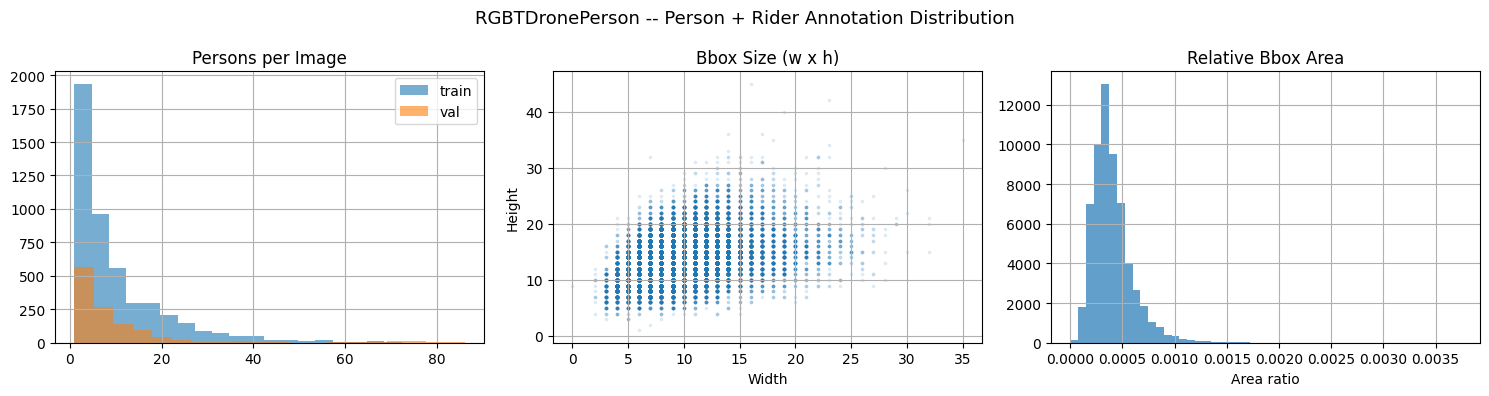

In [6]:
df_person = df[df['class'].isin(['person', 'rider'])].copy()
df_person['rel_area'] = (df_person['bbox_w'] * df_person['bbox_h']) / (
    df_person['img_w'] * df_person['img_h']
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

per_img = df_person.groupby(['split', 'stem']).size().reset_index(name='count')
for split, grp in per_img.groupby('split'):
    axes[0].hist(grp['count'], bins=20, alpha=0.6, label=split)
axes[0].set_title('Persons per Image'); axes[0].legend(); axes[0].grid(True)

axes[1].scatter(df_person['bbox_w'], df_person['bbox_h'], alpha=0.1, s=3)
axes[1].set(title='Bbox Size (w x h)', xlabel='Width', ylabel='Height'); axes[1].grid(True)

axes[2].hist(df_person['rel_area'], bins=50, alpha=0.7)
axes[2].set(title='Relative Bbox Area', xlabel='Area ratio'); axes[2].grid(True)

plt.suptitle('RGBTDronePerson -- Person + Rider Annotation Distribution', fontsize=13)
plt.tight_layout()
plt.show()

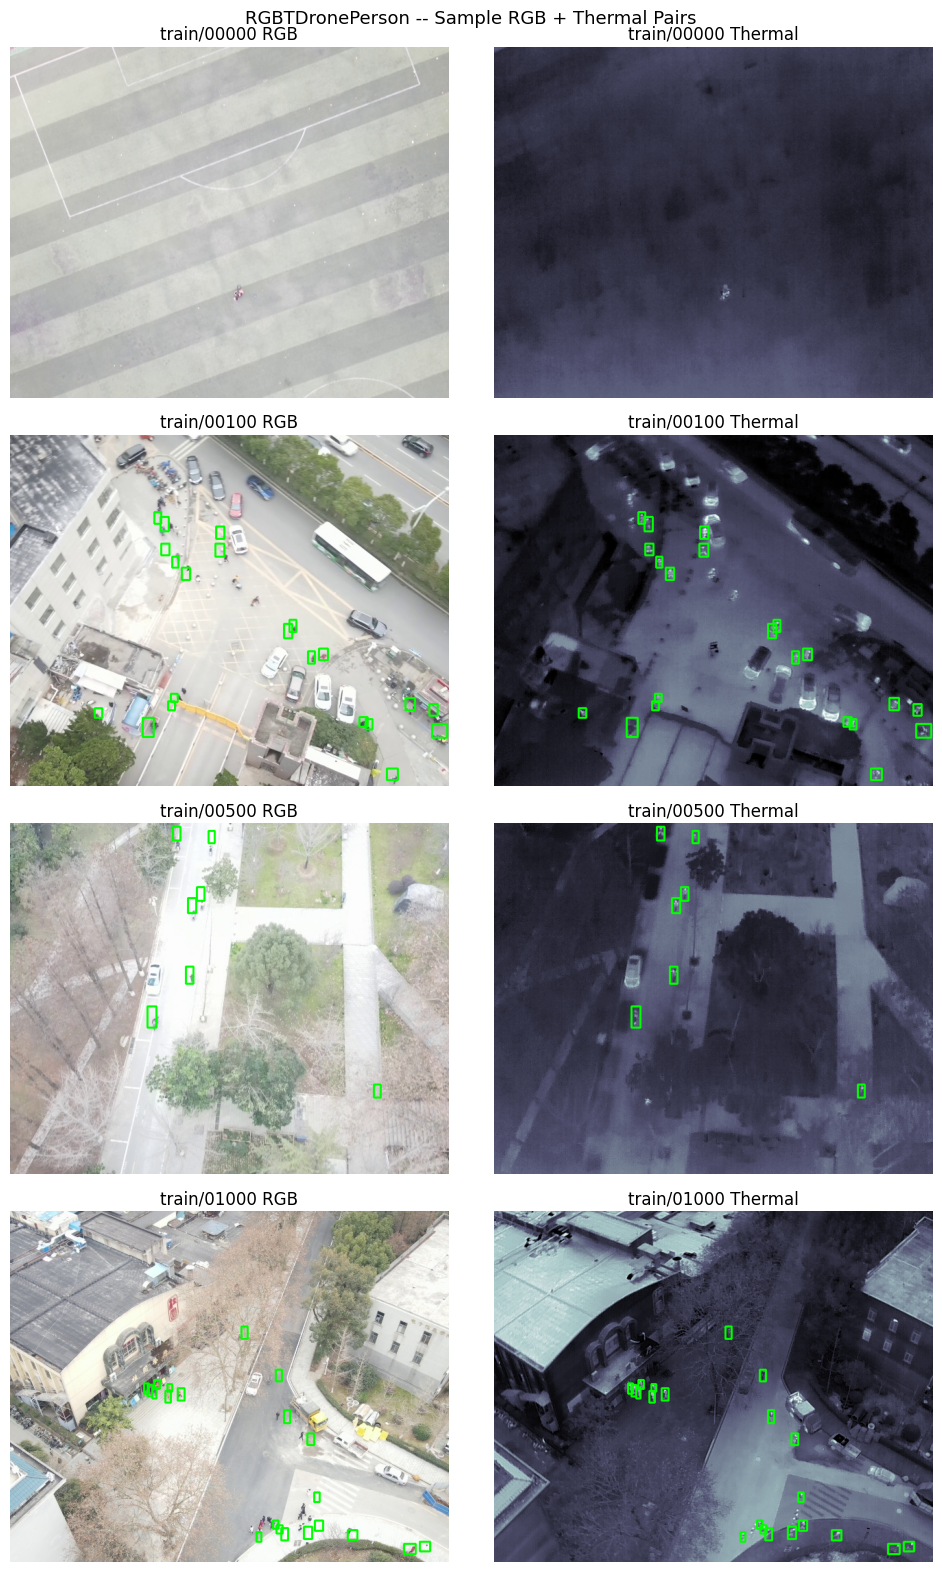

In [7]:
# Hiển thị mẫu cặp RGB + Thermal
sample_stems = ['00000', '00100', '00500', '01000']
fig, axes = plt.subplots(len(sample_stems), 2, figsize=(10, 4 * len(sample_stems)))

for row, stem in enumerate(sample_stems):
    for split in ['train', 'val']:
        rgb_path = Path(RGBT_DATA_DIR) / split / 'visible' / f'{stem}.jpg'
        thr_path = Path(RGBT_DATA_DIR) / split / 'thermal' / f'{stem}.jpg'
        xml_path = Path(RGBT_DATA_DIR) / split / 'annotation' / f'{stem}.xml'
        if not rgb_path.exists():
            continue

        rgb = cv2.cvtColor(cv2.imread(str(rgb_path)), cv2.COLOR_BGR2RGB)
        thr = cv2.imread(str(thr_path), cv2.IMREAD_GRAYSCALE)
        thr_c = cv2.cvtColor(cv2.applyColorMap(thr, cv2.COLORMAP_BONE), cv2.COLOR_BGR2RGB)

        objs = parse_voc_xml(xml_path)
        for cls, x1, y1, x2, y2, _, _ in objs:
            if cls in ('person', 'rider'):
                cv2.rectangle(rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.rectangle(thr_c, (x1, y1), (x2, y2), (0, 255, 0), 2)

        axes[row, 0].imshow(rgb);   axes[row, 0].set_title(f'{split}/{stem} RGB');     axes[row, 0].axis('off')
        axes[row, 1].imshow(thr_c); axes[row, 1].set_title(f'{split}/{stem} Thermal'); axes[row, 1].axis('off')
        break

plt.suptitle('RGBTDronePerson -- Sample RGB + Thermal Pairs', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Tiền xử lý -- VOC XML sang YOLO format

Chuyển annotation VOC XML sang YOLO `.txt` (class cx cy w h, normalized).
Gộp nhãn `person` và `rider` thành class 0.

In [8]:
def voc_to_yolo(xmin, ymin, xmax, ymax, img_w, img_h):
    """Chuyển VOC bbox sang YOLO normalized format."""
    cx = (xmin + xmax) / 2.0 / img_w
    cy = (ymin + ymax) / 2.0 / img_h
    w  = (xmax - xmin) / img_w
    h  = (ymax - ymin) / img_h
    return [min(max(v, 0.0), 1.0) for v in [cx, cy, w, h]]


CLASS_MAP = {'person': 0, 'rider': 0}

existing_labels = list(Path(FUSION_YOLO_DIR, 'labels', 'train').glob('*.txt')) if os.path.exists(os.path.join(FUSION_YOLO_DIR, 'labels', 'train')) else []
if len(existing_labels) > 0:
    print(f'Dữ liệu YOLO đã tồn tại ({len(existing_labels)} labels). Bỏ qua bước convert.')
else:
    for modality in ['rgb', 'thermal']:
        for split in ['train', 'val']:
            os.makedirs(os.path.join(FUSION_YOLO_DIR, 'images', modality, split), exist_ok=True)
    for split in ['train', 'val']:
        os.makedirs(os.path.join(FUSION_YOLO_DIR, 'labels', split), exist_ok=True)

    stats = {'converted': 0, 'no_person': 0, 'errors': 0}

    for split in ['train', 'val']:
        ann_dir = Path(RGBT_DATA_DIR) / split / 'annotation'
        vis_dir = Path(RGBT_DATA_DIR) / split / 'visible'
        thr_dir = Path(RGBT_DATA_DIR) / split / 'thermal'

        for xml_file in sorted(ann_dir.glob('*.xml')):
            stem = xml_file.stem
            try:
                objs = parse_voc_xml(xml_file)
            except Exception:
                stats['errors'] += 1
                continue

            person_objs = [o for o in objs if o[0] in CLASS_MAP]
            if not person_objs:
                stats['no_person'] += 1
                continue

            label_path = os.path.join(FUSION_YOLO_DIR, 'labels', split, f'{stem}.txt')
            with open(label_path, 'w') as f:
                for cls, xmin, ymin, xmax, ymax, img_w, img_h in person_objs:
                    cx, cy, w, h = voc_to_yolo(xmin, ymin, xmax, ymax, img_w, img_h)
                    if w > 0 and h > 0:
                        f.write(f'{CLASS_MAP[cls]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n')

            rgb_src = vis_dir / f'{stem}.jpg'
            thr_src = thr_dir / f'{stem}.jpg'
            for src, mod in [(rgb_src, 'rgb'), (thr_src, 'thermal')]:
                dst = os.path.join(FUSION_YOLO_DIR, 'images', mod, split, f'{stem}.jpg')
                if src.exists() and not os.path.exists(dst):
                    shutil.copy2(str(src), dst)

            stats['converted'] += 1

    print(f"Đã chuyển đổi: {stats['converted']} ảnh")
    print(f"Không có person: {stats['no_person']} ảnh (bỏ qua)")
    print(f"Lỗi: {stats['errors']}")

print()
for split in ['train', 'val']:
    n_rgb = len(list(Path(FUSION_YOLO_DIR, 'images', 'rgb', split).glob('*.jpg')))
    n_thr = len(list(Path(FUSION_YOLO_DIR, 'images', 'thermal', split).glob('*.jpg')))
    n_lbl = len(list(Path(FUSION_YOLO_DIR, 'labels', split).glob('*.txt')))
    print(f'  {split}: rgb={n_rgb}, thermal={n_thr}, labels={n_lbl}')

Dữ liệu YOLO đã tồn tại (4760 labels). Bỏ qua bước convert.

  train: rgb=4760, thermal=4760, labels=4760
  val: rgb=1207, thermal=1207, labels=1207


## 5. Kiến trúc mô hình Mid-Level Fusion

```
Đầu vào 640x640
  RGB -----> [YOLOv8n backbone LLVIP RGB] --> P3(64), P4(128), P5(256) --+
                                                                              |-> [Concat + 1x1 Conv] -> [Neck FPN+PAN] -> [Detect]
  Thermal -> [YOLOv8n backbone LLVIP]         --> P3(64), P4(128), P5(256) --+
```

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def load_yolov8n_backbone(backbone_path):
    """Load YOLOv8n backbone (layers 0-9) từ file .pt."""
    if backbone_path and os.path.exists(backbone_path):
        try:
            yolo = YOLO(backbone_path)
            bb = nn.ModuleList(list(yolo.model.model)[:10])
            print(f'  Đã load backbone từ: {backbone_path}')
            return bb.to(device)
        except Exception as e:
            print(f'  Lỗi load YOLO: {e}')
            try:
                ckpt = torch.load(backbone_path, map_location=device, weights_only=False)
                state = ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt))
                base = YOLO('yolov8n.pt')
                full_s = base.model.state_dict()
                for k, v in state.items():
                    if k in full_s and full_s[k].shape == v.shape:
                        full_s[k] = v
                base.model.load_state_dict(full_s)
                bb = nn.ModuleList(list(base.model.model)[:10])
                print(f'  Đã load backbone qua state_dict: {backbone_path}')
                return bb.to(device)
            except Exception as e2:
                print(f'  Fallback state_dict cũng thất bại: {e2}')

    print(f'  CẢNH BÁO: {backbone_path} không tìm thấy -> dùng yolov8n.pt mặc định')
    base = YOLO('yolov8n.pt')
    return nn.ModuleList(list(base.model.model)[:10]).to(device)


# Xác nhận kích thước output
base_yolo = YOLO('yolov8n.pt')
bb_test = nn.ModuleList(list(base_yolo.model.model)[:10]).to(device).eval()
dummy = torch.zeros(1, 3, 640, 640, device=device)
x = dummy
print('\nKích thước output backbone YOLOv8n:')
with torch.no_grad():
    for i, layer in enumerate(bb_test):
        x = layer(x)
        if i in [4, 6, 9]:
            print(f'  Layer {i} (P{3 if i==4 else 4 if i==6 else 5}): {tuple(x.shape)}')
del bb_test, dummy, x, base_yolo
torch.cuda.empty_cache()

Device: cuda

Kích thước output backbone YOLOv8n:
  Layer 4 (P3): (1, 64, 80, 80)
  Layer 6 (P4): (1, 128, 40, 40)
  Layer 9 (P5): (1, 256, 20, 20)


In [10]:
class RGBTFusionDetector(nn.Module):
    """Mid-level fusion: 2 frozen backbones -> concat features -> 1x1 Conv -> Neck -> Detect."""

    EXTRACT_LAYERS = {4: 64, 6: 128, 9: 256}

    def __init__(self, rgb_backbone, thermal_backbone, nc=1, freeze_backbones=True):
        super().__init__()
        self.rgb_stream     = rgb_backbone
        self.thermal_stream = thermal_backbone

        if freeze_backbones:
            for p in self.rgb_stream.parameters():
                p.requires_grad = False
            for p in self.thermal_stream.parameters():
                p.requires_grad = False

        self.fuse_p3 = nn.Sequential(nn.Conv2d(128, 128, 1, bias=False), nn.BatchNorm2d(128), nn.SiLU())
        self.fuse_p4 = nn.Sequential(nn.Conv2d(256, 256, 1, bias=False), nn.BatchNorm2d(256), nn.SiLU())
        self.fuse_p5 = nn.Sequential(nn.Conv2d(512, 512, 1, bias=False), nn.BatchNorm2d(512), nn.SiLU())

        self.upsample   = nn.Upsample(scale_factor=2, mode='nearest')
        self.td_c2f_p4  = C2f(512 + 256, 256, n=1, shortcut=False)
        self.td_c2f_p3  = C2f(256 + 128, 128, n=1, shortcut=False)
        self.bu_conv_p4 = Conv(128, 128, 3, 2)
        self.bu_c2f_p4  = C2f(128 + 256, 256, n=1, shortcut=False)
        self.bu_conv_p5 = Conv(256, 256, 3, 2)
        self.bu_c2f_p5  = C2f(256 + 512, 512, n=1, shortcut=False)

        self.detect = Detect(nc=nc, ch=(128, 256, 512))
        self.detect.stride = torch.tensor([8., 16., 32.])

    def _extract_features(self, stream, x):
        feats = {}
        for i, layer in enumerate(stream):
            x = layer(x)
            if i in self.EXTRACT_LAYERS:
                feats[i] = x
        return feats

    def forward(self, rgb, thermal):
        rgb_f = self._extract_features(self.rgb_stream, rgb)
        thr_f = self._extract_features(self.thermal_stream, thermal)

        p3 = self.fuse_p3(torch.cat([rgb_f[4], thr_f[4]], dim=1))
        p4 = self.fuse_p4(torch.cat([rgb_f[6], thr_f[6]], dim=1))
        p5 = self.fuse_p5(torch.cat([rgb_f[9], thr_f[9]], dim=1))

        p4_td  = self.td_c2f_p4(torch.cat([self.upsample(p5), p4], dim=1))
        p3_out = self.td_c2f_p3(torch.cat([self.upsample(p4_td), p3], dim=1))

        p4_out = self.bu_c2f_p4(torch.cat([self.bu_conv_p4(p3_out), p4_td], dim=1))
        p5_out = self.bu_c2f_p5(torch.cat([self.bu_conv_p5(p4_out), p5], dim=1))

        return self.detect([p3_out, p4_out, p5_out])


print('RGBTFusionDetector đã định nghĩa.')

RGBTFusionDetector đã định nghĩa.


## 6. Dataset và DataLoader

In [11]:
class RGBTDataset(Dataset):
    """Dataset cho cặp ảnh RGB-Thermal với augmentation."""

    def __init__(self, fusion_yolo_dir, split='train', img_size=640,
                 blur_prob=0.5, blur_kernels=(3, 5, 7), blur_sigma=(0.5, 2.0),
                 flip_prob=0.5):
        self.img_size = img_size
        self.split = split
        self.is_train = (split == 'train')

        self.blur_prob = blur_prob if self.is_train else 0.0
        self.blur_kernels = blur_kernels
        self.blur_sigma = blur_sigma
        self.flip_prob = flip_prob if self.is_train else 0.0

        self.rgb_dir = Path(fusion_yolo_dir) / 'images' / 'rgb' / split
        self.thr_dir = Path(fusion_yolo_dir) / 'images' / 'thermal' / split
        self.lbl_dir = Path(fusion_yolo_dir) / 'labels' / split

        rgb_stems = {p.stem for p in self.rgb_dir.glob('*.jpg')}
        thr_stems = {p.stem for p in self.thr_dir.glob('*.jpg')}
        lbl_stems = {p.stem for p in self.lbl_dir.glob('*.txt')}
        self.stems = sorted(rgb_stems & thr_stems & lbl_stems)

        self.resize = T.Resize((img_size, img_size))
        self.to_tensor = T.ToTensor()

        aug_info = []
        if self.blur_prob > 0:
            aug_info.append(f'blur(p={self.blur_prob}, k={self.blur_kernels})')
        if self.flip_prob > 0:
            aug_info.append(f'hflip(p={self.flip_prob})')
        aug_str = ', '.join(aug_info) if aug_info else 'không có'
        print(f'RGBTDataset [{split}]: {len(self.stems)} mẫu | augment: {aug_str}')

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]

        rgb_img = Image.open(self.rgb_dir / f'{stem}.jpg').convert('RGB')
        thr_img = Image.open(self.thr_dir / f'{stem}.jpg').convert('L').convert('RGB')

        rgb_img = self.resize(rgb_img)
        thr_img = self.resize(thr_img)

        # Random Gaussian Blur (chỉ RGB) -- giảm ảnh hưởng lệch vị trí RGB-Thermal
        if random.random() < self.blur_prob:
            k = random.choice(self.blur_kernels)
            sigma = random.uniform(self.blur_sigma[0], self.blur_sigma[1])
            rgb_img = TF.gaussian_blur(rgb_img, kernel_size=[k, k], sigma=[sigma, sigma])

        labels = []
        with open(self.lbl_dir / f'{stem}.txt') as f:
            for line in f:
                v = list(map(float, line.strip().split()))
                if len(v) == 5:
                    labels.append(v)

        # Random Horizontal Flip (RGB + Thermal + bbox đồng thời)
        if random.random() < self.flip_prob:
            rgb_img = TF.hflip(rgb_img)
            thr_img = TF.hflip(thr_img)
            labels = [[v[0], 1.0 - v[1], v[2], v[3], v[4]] for v in labels]

        rgb = self.to_tensor(rgb_img)
        thr = self.to_tensor(thr_img)
        lbl_t = torch.tensor(labels, dtype=torch.float32) if labels else torch.zeros((0, 5))
        return rgb, thr, lbl_t, stem


def collate_fn(batch):
    rgbs, thrs, labels_list, stems = zip(*batch)
    rgbs = torch.stack(rgbs)
    thrs = torch.stack(thrs)
    out = []
    for i, lbl in enumerate(labels_list):
        if lbl.shape[0] > 0:
            out.append(torch.cat([torch.full((len(lbl), 1), i), lbl], dim=1))
    batch_labels = torch.cat(out, dim=0) if out else torch.zeros((0, 6))
    return rgbs, thrs, batch_labels, stems


train_ds = RGBTDataset(FUSION_YOLO_DIR, 'train', img_size=IMG_SIZE,
                       blur_prob=0.5, blur_kernels=(3, 5, 7), blur_sigma=(0.5, 2.0), flip_prob=0.5)
val_ds   = RGBTDataset(FUSION_YOLO_DIR, 'val', img_size=IMG_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f'\nBatch huấn luyện: {len(train_loader)} | Batch đánh giá: {len(val_loader)}')

RGBTDataset [train]: 4760 mẫu | augment: blur(p=0.5, k=(3, 5, 7)), hflip(p=0.5)
RGBTDataset [val]: 1207 mẫu | augment: không có

Batch huấn luyện: 149 | Batch đánh giá: 38


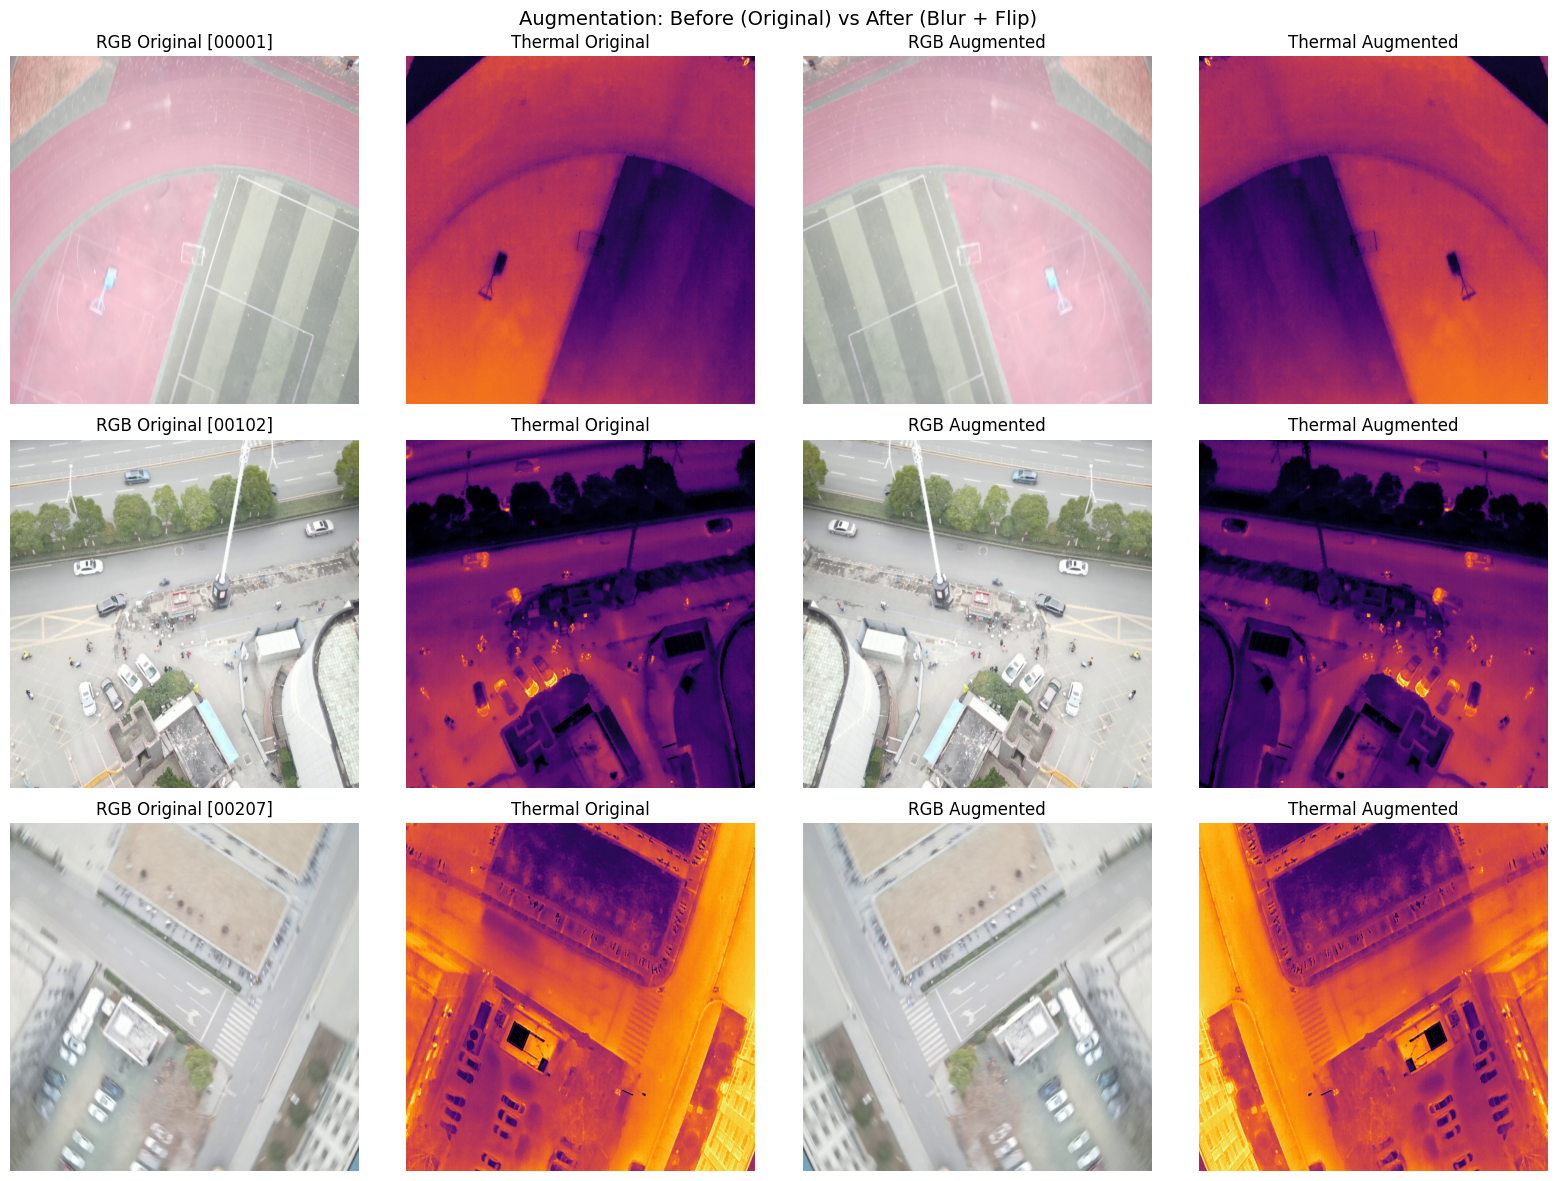

In [12]:
# Hiển thị ảnh trước/sau augmentation
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Augmentation: Before (Original) vs After (Blur + Flip)', fontsize=14)

for row in range(3):
    idx = row * 100
    if idx >= len(train_ds):
        break

    stem = train_ds.stems[idx]
    rgb_orig = Image.open(train_ds.rgb_dir / f'{stem}.jpg').convert('RGB')
    thr_orig = Image.open(train_ds.thr_dir / f'{stem}.jpg').convert('L')
    rgb_orig = train_ds.resize(rgb_orig)
    thr_orig = train_ds.resize(thr_orig)

    axes[row, 0].imshow(rgb_orig); axes[row, 0].set_title(f'RGB Original [{stem}]'); axes[row, 0].axis('off')
    axes[row, 1].imshow(thr_orig, cmap='inferno'); axes[row, 1].set_title('Thermal Original'); axes[row, 1].axis('off')

    rgb_aug, thr_aug, _, _ = train_ds[idx]
    axes[row, 2].imshow(rgb_aug.permute(1, 2, 0).numpy()); axes[row, 2].set_title('RGB Augmented'); axes[row, 2].axis('off')
    axes[row, 3].imshow(thr_aug[0].numpy(), cmap='inferno'); axes[row, 3].set_title('Thermal Augmented'); axes[row, 3].axis('off')

plt.tight_layout()
plt.show()

## 7. Hàm huấn luyện

In [13]:
def set_seed(seed):
    """Đặt seed cho tái lập kết quả."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class _LossModel(nn.Module):
    """Wrapper để tương thích với v8DetectionLoss."""
    def __init__(self, detector):
        super().__init__()
        d = detector.module if isinstance(detector, nn.DataParallel) else detector
        self.model = nn.ModuleList([d.detect])
        self.nc    = d.detect.nc
        self.args  = type('a', (), {
            'box': 7.5, 'cls': 0.5, 'dfl': 1.5,
            'pose': 12.0, 'kobj': 1.0
        })()


def run_epoch(model, loader, optimizer, criterion, device, train=True):
    """Chạy 1 epoch. Trả về loss trung bình."""
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for batch_idx, (rgb, thr, labels, _) in enumerate(loader):
            rgb    = rgb.to(device)
            thr    = thr.to(device)
            labels = labels.to(device)

            preds = model(rgb, thr)
            batch_size = rgb.shape[0]

            batch_dict = {
                'cls':       labels[:, 1:2],
                'bboxes':    labels[:, 2:6],
                'batch_idx': labels[:, 0],
                'img':       rgb,
            }
            loss_result = criterion(preds, batch_dict)

            if isinstance(loss_result, (tuple, list)):
                loss = loss_result[0].sum()
            else:
                loss = loss_result.sum()

            loss = loss / batch_size

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], GRAD_CLIP
                )
                optimizer.step()

            total_loss += loss.item()
            n += 1

            if train and batch_idx % 50 == 0:
                print(f'    [{batch_idx:4d}/{len(loader)}] loss={loss.item():.4f}')

    return total_loss / max(n, 1)

## 8. Huấn luyện -- 3 Seeds

In [14]:
all_histories = {}
all_results = {}

for seed_idx, SEED in enumerate(SEEDS):
    seed_dir = os.path.join(FUSION_OUTPUT_DIR, f'seed_{SEED}')
    os.makedirs(seed_dir, exist_ok=True)
    best_path = os.path.join(seed_dir, 'fusion_best.pt')

    if os.path.exists(best_path):
        ckpt = torch.load(best_path, map_location=device, weights_only=False)
        if 'metrics' in ckpt:
            all_results[SEED] = ckpt['metrics']
        all_histories[SEED] = ckpt.get('history', {})
        print(f'Seed {SEED}: đã có checkpoint (epoch {ckpt.get("epoch","?")}), bỏ qua training.')
        continue

    print(f'\n{"="*60}')
    print(f'  SEED {SEED} ({seed_idx+1}/{len(SEEDS)})')
    print(f'{"="*60}')

    set_seed(SEED)

    rgb_bb = load_yolov8n_backbone(RGB_BACKBONE_PATH)
    thr_bb = load_yolov8n_backbone(THERMAL_BACKBONE_PATH)
    fusion_model = RGBTFusionDetector(rgb_bb, thr_bb, nc=1, freeze_backbones=True)
    if torch.cuda.device_count() > 1:
        print(f'Using {torch.cuda.device_count()} GPUs (DataParallel)')
        fusion_model = nn.DataParallel(fusion_model)
    fusion_model = fusion_model.to(device)

    trainable = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in fusion_model.parameters())
    print(f'Tham số: {total:,} tổng | {trainable:,} huấn luyện ({100*trainable/total:.1f}%)')

    optimizer = AdamW(
        [p for p in fusion_model.parameters() if p.requires_grad],
        lr=LR, weight_decay=WEIGHT_DECAY
    )

    def lr_lambda(epoch):
        if epoch < WARMUP_EPOCHS:
            return 0.01 + (1.0 - 0.01) * epoch / max(WARMUP_EPOCHS, 1)
        else:
            progress = (epoch - WARMUP_EPOCHS) / max(NUM_EPOCHS - WARMUP_EPOCHS, 1)
            return 0.01 + 0.5 * (1.0 - 0.01) * (1 + math.cos(math.pi * progress))

    scheduler = LambdaLR(optimizer, lr_lambda)
    criterion = v8DetectionLoss(_LossModel(fusion_model))

    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val = float('inf')
    no_improve = 0

    print(f'Bắt đầu huấn luyện {NUM_EPOCHS} epoch trên {device}...')

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tr_loss = run_epoch(fusion_model, train_loader, optimizer, criterion, device, train=True)
        va_loss = run_epoch(fusion_model, val_loader,   optimizer, criterion, device, train=False)
        scheduler.step()
        lr = scheduler.get_last_lr()[0]

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['lr'].append(lr)

        flag = ''
        if va_loss < best_val:
            best_val = va_loss
            no_improve = 0
            torch.save({
                'epoch': epoch, 'seed': SEED,
                'model_state_dict': (fusion_model.module.state_dict() if isinstance(fusion_model, nn.DataParallel) else fusion_model.state_dict()),
                'val_loss': va_loss, 'train_loss': tr_loss,
                'history': history
            }, best_path)
            flag = '  <- tốt nhất'
        else:
            no_improve += 1
            flag = f'  (không cải thiện {no_improve}/{PATIENCE})'

        elapsed = time.time() - t0
        print(f'Epoch {epoch:3d}/{NUM_EPOCHS}  train={tr_loss:.4f}  val={va_loss:.4f}  '
              f'lr={lr:.2e}  {elapsed:.0f}s{flag}')

        if no_improve >= PATIENCE:
            print(f'Early stopping tại epoch {epoch}')
            break

    all_histories[SEED] = history
    print(f'Seed {SEED}: hoàn thành. Val loss tốt nhất = {best_val:.4f}')

    del fusion_model, optimizer, scheduler, criterion, rgb_bb, thr_bb
    torch.cuda.empty_cache()
    gc.collect()

print(f'\nĐã hoàn thành huấn luyện {len(SEEDS)} seeds.')


  SEED 42 (1/3)
  Đã load backbone từ: /root/AIP491/backbones/llvip_rgb_best.pt
  Đã load backbone từ: /root/AIP491/backbones/llvip_thermal_best.pt
Tham số: 7,650,803 tổng | 5,105,475 huấn luyện (66.7%)
Bắt đầu huấn luyện 50 epoch trên cuda...
    [   0/149] loss=103696.8125
    [  50/149] loss=101546.5234
    [ 100/149] loss=98704.2734
Epoch   1/50  train=99509.8502  val=81109.0262  lr=1.04e-04  77s  <- tốt nhất
    [   0/149] loss=95716.4766
    [  50/149] loss=557.0664
    [ 100/149] loss=181.6127
Epoch   2/50  train=14955.9345  val=317.3556  lr=2.03e-04  88s  <- tốt nhất
    [   0/149] loss=171.8915
    [  50/149] loss=129.3977
    [ 100/149] loss=69.9596
Epoch   3/50  train=104.2432  val=113.4292  lr=3.02e-04  74s  <- tốt nhất
    [   0/149] loss=51.0205
    [  50/149] loss=36.7704
    [ 100/149] loss=19.2333
Epoch   4/50  train=35.8163  val=23.7675  lr=4.01e-04  77s  <- tốt nhất
    [   0/149] loss=13.7011
    [  50/149] loss=11.4649
    [ 100/149] loss=6.7561
Epoch   5/50  trai

## 9. Biểu đồ Loss và Learning Rate

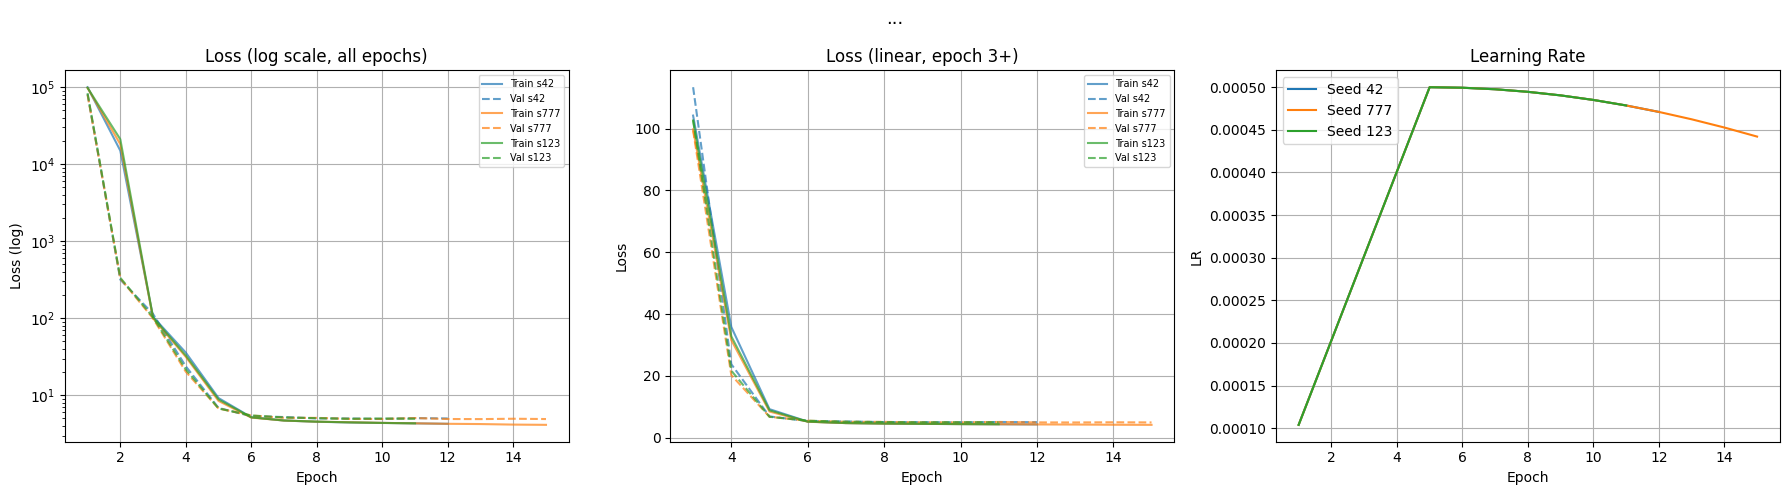

In [15]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
SKIP = 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax1, ax1b, ax2 = axes

for i, seed in enumerate(SEEDS):
    if seed not in all_histories:
        continue
    h = all_histories[seed]
    ep     = list(range(1, len(h['train_loss']) + 1))
    ep_cut = ep[SKIP:]
    tr_cut = h['train_loss'][SKIP:]
    va_cut = h['val_loss'][SKIP:]

    ax1.semilogy(ep, h['train_loss'], color=colors[i], linestyle='-',  alpha=0.7, label=f'Train s{seed}')
    ax1.semilogy(ep, h['val_loss'],   color=colors[i], linestyle='--', alpha=0.7, label=f'Val s{seed}')

    ax1b.plot(ep_cut, tr_cut, color=colors[i], linestyle='-',  alpha=0.7, label=f'Train s{seed}')
    ax1b.plot(ep_cut, va_cut, color=colors[i], linestyle='--', alpha=0.7, label=f'Val s{seed}')

    ax2.plot(ep, h['lr'], color=colors[i], label=f'Seed {seed}')

ax1.set(title='Loss (log scale, all epochs)', xlabel='Epoch', ylabel='Loss (log)')
ax1.legend(fontsize=7); ax1.grid(True)
ax1b.set(title=f'Loss (linear, epoch {SKIP+1}+)', xlabel='Epoch', ylabel='Loss')
ax1b.legend(fontsize=7); ax1b.grid(True)
ax2.set(title='Learning Rate', xlabel='Epoch', ylabel='LR')
ax2.legend(); ax2.grid(True)

plt.suptitle('...', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FUSION_OUTPUT_DIR, 'loss_curves_all_seeds.png'), dpi=150)
plt.show()

## 10. Đánh giá mô hình

In [16]:
def custom_nms(prediction, conf_thres=0.25, iou_thres=0.45, nc=1):
    """NMS cho output của Detect head."""
    if prediction.dim() == 3 and prediction.shape[1] < prediction.shape[2]:
        prediction = prediction.transpose(1, 2)
    output = []
    for xi in range(prediction.shape[0]):
        x = prediction[xi]
        box = x[:, :4]
        cls_scores = x[:, 4:4+nc]
        conf, cls_idx = cls_scores.max(dim=1)
        mask = conf >= conf_thres
        box, conf, cls_idx = box[mask], conf[mask], cls_idx[mask]
        if len(box) == 0:
            output.append(torch.zeros((0, 6), device=prediction.device))
            continue
        xyxy = xywh2xyxy(box)
        keep = nms(xyxy, conf, iou_thres)
        output.append(torch.cat([xyxy[keep], conf[keep].unsqueeze(1), cls_idx[keep].float().unsqueeze(1)], dim=1))
    return output


def compute_ap_101(precision_curve, recall_curve):
    """Tính AP theo chuẩn COCO 101-point interpolation."""
    mrec = np.concatenate(([0.0], recall_curve, [1.0]))
    mpre = np.concatenate(([1.0], precision_curve, [0.0]))
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    recall_points = np.linspace(0, 1, 101)
    ap = 0.0
    for r in recall_points:
        indices = np.where(mrec >= r)[0]
        if len(indices) > 0:
            ap += mpre[indices[0]]
    return ap / 101.0


def evaluate_model(model, val_loader, device, nms_iou=0.45):
    """Đánh giá model: P, R, F1, mAP@0.5, mAP@[.5:.95]."""
    model.eval()
    all_pred_boxes, all_pred_scores, all_gt_boxes, all_img_ids = [], [], [], []
    n_gt_total = 0
    img_id = 0

    with torch.no_grad():
        for rgb, thr, labels, _ in val_loader:
            rgb = rgb.to(device)
            thr = thr.to(device)
            preds_raw = model(rgb, thr)
            pred_t = preds_raw[0] if isinstance(preds_raw, (list, tuple)) else preds_raw
            dets_list = custom_nms(pred_t, conf_thres=0.001, iou_thres=nms_iou, nc=1)

            for img_i, dets in enumerate(dets_list):
                gt_mask = labels[:, 0] == img_i
                gt = labels[gt_mask]
                n_gt = len(gt)
                gt_xyxy = xywh2xyxy(gt[:, 2:6]) * IMG_SIZE if n_gt > 0 else torch.zeros((0, 4))
                all_gt_boxes.append(gt_xyxy)
                n_gt_total += n_gt

                if len(dets) > 0:
                    for di in range(len(dets)):
                        all_pred_boxes.append(dets[di, :4].cpu())
                        all_pred_scores.append(float(dets[di, 4].cpu()))
                        all_img_ids.append(img_id)
                img_id += 1

    all_pred_scores_np = np.array(all_pred_scores)
    all_img_ids_np = np.array(all_img_ids)
    sorted_indices = np.argsort(-all_pred_scores_np)

    iou_thresholds = np.arange(0.5, 1.0, 0.05)
    ap_per_iou = {}

    for iou_thresh in iou_thresholds:
        matched_gt = {i: set() for i in range(len(all_gt_boxes))}
        tp_arr = np.zeros(len(sorted_indices))
        fp_arr = np.zeros(len(sorted_indices))

        for rank, det_idx in enumerate(sorted_indices):
            img_id_val = all_img_ids_np[det_idx]
            pred_box = all_pred_boxes[det_idx]
            gt_boxes = all_gt_boxes[img_id_val]
            if len(gt_boxes) == 0:
                fp_arr[rank] = 1
                continue
            ious = box_iou(pred_box.unsqueeze(0), gt_boxes)[0]
            max_iou = ious.max().item()
            max_gt_idx = ious.argmax().item()
            if max_iou >= iou_thresh and max_gt_idx not in matched_gt[img_id_val]:
                tp_arr[rank] = 1
                matched_gt[img_id_val].add(max_gt_idx)
            else:
                fp_arr[rank] = 1

        cum_tp = np.cumsum(tp_arr)
        cum_fp = np.cumsum(fp_arr)
        prec_curve = cum_tp / (cum_tp + cum_fp + 1e-6)
        rec_curve = cum_tp / (n_gt_total + 1e-6)
        ap = compute_ap_101(prec_curve, rec_curve)
        ap_per_iou[f'{iou_thresh:.2f}'] = ap

    map50 = ap_per_iou.get('0.50', 0.0)
    map50_95 = np.mean(list(ap_per_iou.values()))

    # P/R/F1 tại conf>=0.25, IoU>=0.5
    conf_mask = all_pred_scores_np[sorted_indices] >= 0.25
    tp_025, fp_025 = 0, 0
    matched_025 = {i: set() for i in range(len(all_gt_boxes))}
    for rank in range(len(sorted_indices)):
        if not conf_mask[rank]:
            break
        det_idx = sorted_indices[rank]
        img_id_val = all_img_ids_np[det_idx]
        pred_box = all_pred_boxes[det_idx]
        gt_boxes = all_gt_boxes[img_id_val]
        if len(gt_boxes) == 0:
            fp_025 += 1
            continue
        ious = box_iou(pred_box.unsqueeze(0), gt_boxes)[0]
        max_iou = ious.max().item()
        max_gt_idx = ious.argmax().item()
        if max_iou >= 0.5 and max_gt_idx not in matched_025[img_id_val]:
            tp_025 += 1
            matched_025[img_id_val].add(max_gt_idx)
        else:
            fp_025 += 1

    fn_025 = n_gt_total - tp_025
    precision = tp_025 / (tp_025 + fp_025 + 1e-9)
    recall = tp_025 / (tp_025 + fn_025 + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    return {
        'precision': precision, 'recall': recall, 'f1': f1,
        'map50': map50, 'map50_95': map50_95, 'ap_per_iou': ap_per_iou
    }

In [17]:
for SEED in SEEDS:
    seed_dir = os.path.join(FUSION_OUTPUT_DIR, f'seed_{SEED}')
    best_path = os.path.join(seed_dir, 'fusion_best.pt')

    if SEED in all_results and 'map50' in all_results[SEED]:
        print(f'Seed {SEED}: đã có metrics, bỏ qua.')
        continue

    if not os.path.exists(best_path):
        print(f'Seed {SEED}: không tìm thấy checkpoint, bỏ qua.')
        continue

    print(f'\nĐánh giá seed {SEED}...')
    set_seed(SEED)
    rgb_bb = load_yolov8n_backbone(RGB_BACKBONE_PATH)
    thr_bb = load_yolov8n_backbone(THERMAL_BACKBONE_PATH)
    fusion_model = RGBTFusionDetector(rgb_bb, thr_bb, nc=1, freeze_backbones=True)
    if torch.cuda.device_count() > 1:
        print(f'Using {torch.cuda.device_count()} GPUs (DataParallel)')
        fusion_model = nn.DataParallel(fusion_model)
    fusion_model = fusion_model.to(device)

    ckpt = torch.load(best_path, map_location=device, weights_only=False)
    state = ckpt['model_state_dict']
    if isinstance(fusion_model, nn.DataParallel):
        fusion_model.module.load_state_dict(state)
    else:
        fusion_model.load_state_dict(state)
    print(f'  Đã load model (epoch {ckpt["epoch"]}, val_loss={ckpt["val_loss"]:.4f})')

    metrics = evaluate_model(fusion_model, val_loader, device)
    all_results[SEED] = metrics

    ckpt['metrics'] = metrics
    ckpt['history'] = all_histories.get(SEED, {})
    torch.save(ckpt, best_path)

    print(f'  Precision: {metrics["precision"]:.4f}')
    print(f'  Recall:    {metrics["recall"]:.4f}')
    print(f'  F1:        {metrics["f1"]:.4f}')
    print(f'  mAP@0.5:   {metrics["map50"]:.4f}')
    print(f'  mAP@[.5:.95]: {metrics["map50_95"]:.4f}')

    del fusion_model, rgb_bb, thr_bb
    torch.cuda.empty_cache()
    gc.collect()

print(f'\n{"="*70}')
print(f'  BẢNG TỔNG HỢP -- Mid-Level Fusion Luồng 1 Baseline (LLVIP (RGB) + LLVIP (Thermal))')
print(f'{"="*70}')
print(f'{"Seed":<8} {"Precision":>10} {"Recall":>10} {"F1":>10} {"mAP@0.5":>10} {"mAP@[.5:.95]":>14}')
print(f'{"-"*62}')

for seed in SEEDS:
    if seed in all_results:
        m = all_results[seed]
        print(f' {seed:<7} {m["precision"]:>10.4f} {m["recall"]:>10.4f} {m["f1"]:>10.4f} '
              f'{m["map50"]:>10.4f} {m["map50_95"]:>14.4f}')

if len(all_results) > 1:
    print(f'{"-"*62}')
    for metric_name, key in [('Precision', 'precision'), ('Recall', 'recall'), ('F1', 'f1'),
                              ('mAP@0.5', 'map50'), ('mAP@[.5:.95]', 'map50_95')]:
        vals = [all_results[s][key] for s in SEEDS if s in all_results]
        print(f'  {metric_name:<14}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}')
print(f'{"="*70}')


Đánh giá seed 42...
  Đã load backbone từ: /root/AIP491/backbones/llvip_rgb_best.pt
  Đã load backbone từ: /root/AIP491/backbones/llvip_thermal_best.pt
  Đã load model (epoch 10, val_loss=4.9298)
  Precision: 0.6547
  Recall:    0.4893
  F1:        0.5601
  mAP@0.5:   0.5349
  mAP@[.5:.95]: 0.1793

Đánh giá seed 777...
  Đã load backbone từ: /root/AIP491/backbones/llvip_rgb_best.pt
  Đã load backbone từ: /root/AIP491/backbones/llvip_thermal_best.pt
  Đã load model (epoch 13, val_loss=4.9096)
  Precision: 0.6523
  Recall:    0.5160
  F1:        0.5762
  mAP@0.5:   0.5426
  mAP@[.5:.95]: 0.1763

Đánh giá seed 123...
  Đã load backbone từ: /root/AIP491/backbones/llvip_rgb_best.pt
  Đã load backbone từ: /root/AIP491/backbones/llvip_thermal_best.pt
  Đã load model (epoch 9, val_loss=4.9509)
  Precision: 0.6320
  Recall:    0.5117
  F1:        0.5655
  mAP@0.5:   0.5306
  mAP@[.5:.95]: 0.1753

  BẢNG TỔNG HỢP -- Mid-Level Fusion Luồng 1 Baseline (LLVIP (RGB) + LLVIP (Thermal))
Seed      Pre

## 11. Trực quan hóa kết quả nhận diện

In [18]:
def visualize_samples(model, dataset, device, n=4, conf=0.25, nms_iou=0.45):
    """Hiển thị kết quả nhận diện: RGB+GT, Thermal+Pred, Overlay."""
    model.eval()
    indices = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1:
        axes = axes[None, :]

    with torch.no_grad():
        for row, idx in enumerate(indices):
            rgb_t, thr_t, lbl, stem = dataset[idx]
            preds_raw = model(rgb_t.unsqueeze(0).to(device), thr_t.unsqueeze(0).to(device))
            pred_t = preds_raw[0] if isinstance(preds_raw, (list, tuple)) else preds_raw
            dets = custom_nms(pred_t, conf_thres=conf, iou_thres=nms_iou, nc=1)[0]

            rgb_np = (rgb_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8).copy()
            thr_np = (thr_t[0].numpy() * 255).astype(np.uint8)
            thr_c = cv2.cvtColor(cv2.applyColorMap(thr_np, cv2.COLORMAP_BONE), cv2.COLOR_BGR2RGB).copy()
            overlay = rgb_np.copy()

            if lbl.shape[0] > 0:
                for box in (xywh2xyxy(lbl[:, 1:]) * IMG_SIZE).numpy().astype(int):
                    cv2.rectangle(rgb_np, tuple(box[:2]), tuple(box[2:]), (0, 220, 0), 2)
                    cv2.rectangle(overlay, tuple(box[:2]), tuple(box[2:]), (0, 220, 0), 2)

            if dets is not None and len(dets) > 0:
                for p_idx, det in enumerate(dets.cpu().numpy(), start=1):
                    x1, y1, x2, y2, sc, cl = det
                    cv2.rectangle(thr_c, (int(x1), int(y1)), (int(x2), int(y2)), (60, 220, 60), 2)
                    cv2.rectangle(overlay, (int(x1), int(y1)), (int(x2), int(y2)), (255, 60, 60), 2)
                    label = f'Person #{p_idx} {sc:.2f}'
                    (lw, lh), bl = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
                    ly = max(lh + 2, int(y1) - 2)
                    cv2.rectangle(overlay, (int(x1), ly - lh - 2), (int(x1) + lw + 2, ly + bl), (255, 60, 60), -1)
                    cv2.putText(overlay, label, (int(x1) + 1, ly - 1),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

            axes[row, 0].imshow(rgb_np);   axes[row, 0].set_title(f'RGB + GT [{stem}]');  axes[row, 0].axis('off')
            axes[row, 1].imshow(thr_c);    axes[row, 1].set_title('Thermal + Prediction');    axes[row, 1].axis('off')
            axes[row, 2].imshow(overlay);  axes[row, 2].set_title('Overlay GT + Prediction');  axes[row, 2].axis('off')

    plt.suptitle('Green = Ground Truth | Red = Prediction', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(FUSION_OUTPUT_DIR, 'inference_viz.png'), dpi=150)
    plt.show()

  Đã load backbone từ: /root/AIP491/backbones/llvip_rgb_best.pt
  Đã load backbone từ: /root/AIP491/backbones/llvip_thermal_best.pt


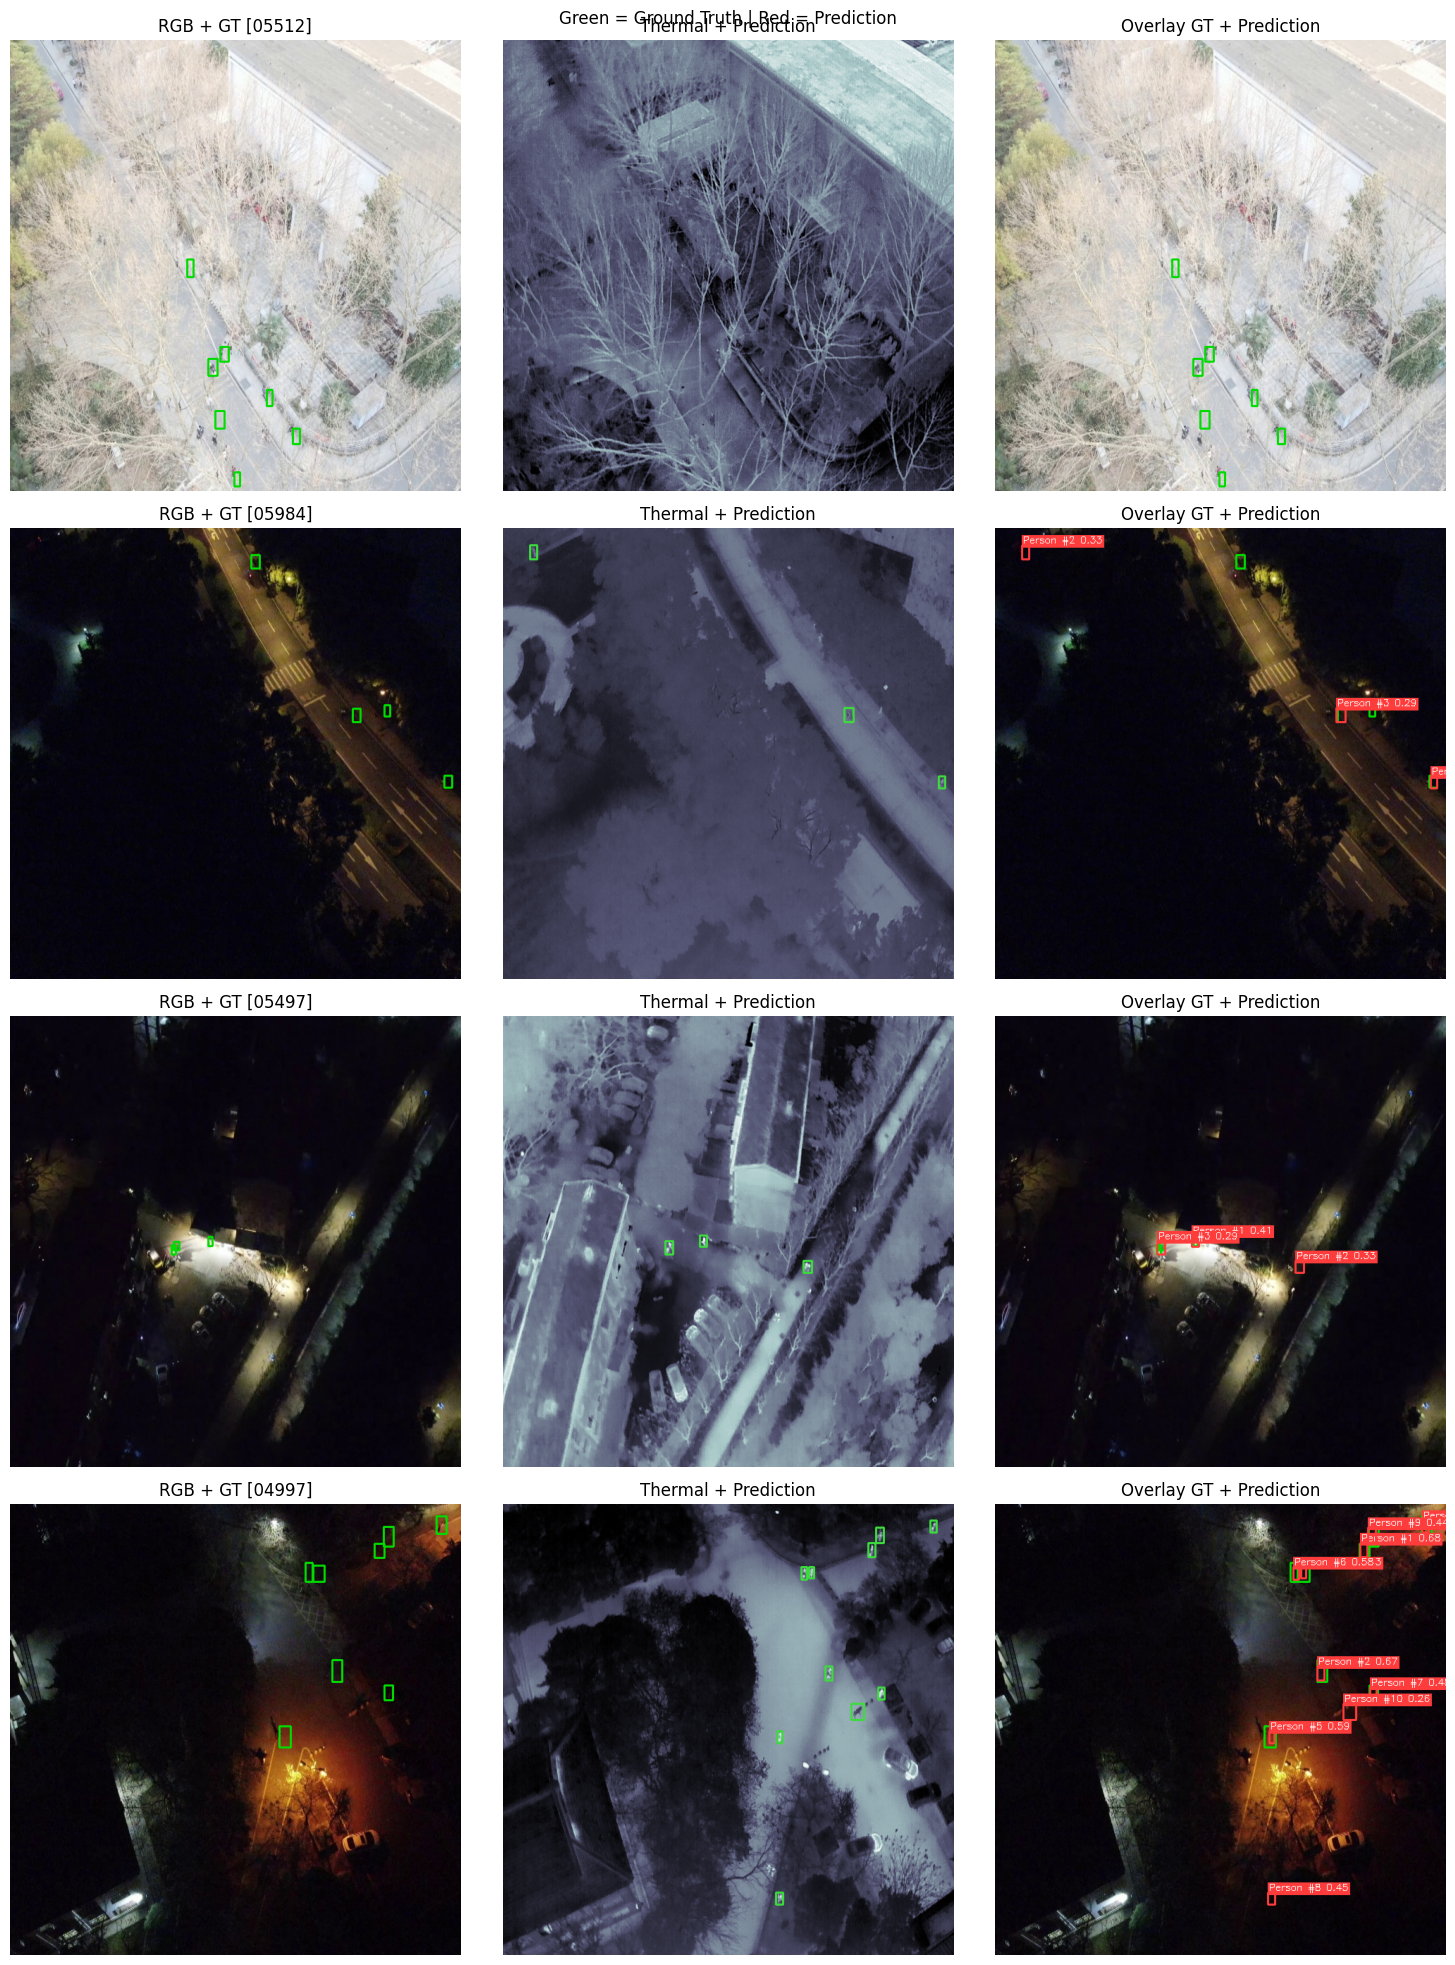

In [19]:
# Hiển thị với model seed đầu tiên
best_seed = SEEDS[0]
seed_dir = os.path.join(FUSION_OUTPUT_DIR, f'seed_{best_seed}')
best_path = os.path.join(seed_dir, 'fusion_best.pt')

rgb_bb = load_yolov8n_backbone(RGB_BACKBONE_PATH)
thr_bb = load_yolov8n_backbone(THERMAL_BACKBONE_PATH)
fusion_model = RGBTFusionDetector(rgb_bb, thr_bb, nc=1, freeze_backbones=True)
if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs (DataParallel)')
    fusion_model = nn.DataParallel(fusion_model)
fusion_model = fusion_model.to(device)
ckpt = torch.load(best_path, map_location=device, weights_only=False)
state = ckpt['model_state_dict']
# Nếu checkpoint save từ non-DataParallel nhưng model hiện tại là DataParallel
if isinstance(fusion_model, nn.DataParallel):
    fusion_model.module.load_state_dict(state)
else:
    fusion_model.load_state_dict(state)

visualize_samples(fusion_model, val_ds, device, n=4)

del fusion_model, rgb_bb, thr_bb
torch.cuda.empty_cache()

## 12. Lưu kết quả và tóm tắt

In [20]:
import csv

csv_path = os.path.join(FUSION_OUTPUT_DIR, 'metrics_summary.csv')
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Seed', 'Precision', 'Recall', 'F1', 'mAP@0.5', 'mAP@[.5:.95]'])
    for seed in SEEDS:
        if seed in all_results:
            m = all_results[seed]
            writer.writerow([seed, f'{m["precision"]:.4f}', f'{m["recall"]:.4f}',
                           f'{m["f1"]:.4f}', f'{m["map50"]:.4f}', f'{m["map50_95"]:.4f}'])
    if len(all_results) > 1:
        means = {k: np.mean([all_results[s][k] for s in SEEDS if s in all_results])
                 for k in ['precision', 'recall', 'f1', 'map50', 'map50_95']}
        stds = {k: np.std([all_results[s][k] for s in SEEDS if s in all_results])
                for k in ['precision', 'recall', 'f1', 'map50', 'map50_95']}
        writer.writerow(['Mean', f'{means["precision"]:.4f}', f'{means["recall"]:.4f}',
                        f'{means["f1"]:.4f}', f'{means["map50"]:.4f}', f'{means["map50_95"]:.4f}'])
        writer.writerow(['Std', f'{stds["precision"]:.4f}', f'{stds["recall"]:.4f}',
                        f'{stds["f1"]:.4f}', f'{stds["map50"]:.4f}', f'{stds["map50_95"]:.4f}'])

print(f'Đã lưu metrics tại: {csv_path}')

history_path = os.path.join(FUSION_OUTPUT_DIR, 'all_histories.json')
histories_ser = {}
for seed, h in all_histories.items():
    histories_ser[str(seed)] = {k: [float(v) for v in vals] for k, vals in h.items()}
with open(history_path, 'w') as f:
    json.dump(histories_ser, f, indent=2)
print(f'Đã lưu training history tại: {history_path}')
print('\nHoàn thành.')

Đã lưu metrics tại: /root/AIP491/Mid-fusion/outputs/baseline_luong1/metrics_summary.csv
Đã lưu training history tại: /root/AIP491/Mid-fusion/outputs/baseline_luong1/all_histories.json

Hoàn thành.
